# Классческая МЛ. Сессионное задание.

## Импорт библиотек

In [40]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    Birch
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

## Загрузка данных и Первичный анализ данных

In [41]:
df = pd.read_csv('data/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
df = df.drop([0, 1, 2, 3, 504], axis=1)
df.columns = list(range(500))
df.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [42]:
# типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, 0 to 499
dtypes: int64(500)
memory usage: 89.6 MB


In [43]:
# статистика
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,14822.972316,14822.958474,14822.970016,14822.989991,14823.003961,14822.978619,14822.968610,14822.954470,14822.963670,14822.968908,...,14822.329017,14822.315686,14822.272073,14822.171728,14822.257123,14822.317092,14822.279399,14822.278163,14822.287789,14822.283743
std,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,2.831241,2.827526,2.846291,2.814655,...,3.357997,3.373568,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307
min,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14809.000000,...,14800.000000,14798.000000,14802.000000,14796.000000,14802.000000,14801.000000,14798.000000,14804.000000,14800.000000,14802.000000
25%,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,...,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000
50%,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,...,14823.000000,14823.000000,14823.000000,14822.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000
75%,14824.000000,14824.000000,14825.000000,14825.000000,14825.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,...,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000
max,14834.000000,14835.000000,14834.000000,14835.000000,14834.000000,14835.000000,14835.000000,14833.000000,14834.000000,14834.000000,...,14836.000000,14835.000000,14834.000000,14836.000000,14833.000000,14834.000000,14833.000000,14834.000000,14833.000000,14835.000000


__Вывод:__
- Датасет содержит 23 479 объектов и 500 признаков. Каждый объект представляет собой один зарегистрированный сигнал.
- Все признаки являются числовыми и имеют тип int64.

## Проверка качества данных

In [44]:
# Пропуски
df.isnull().sum().sum()

np.int64(0)

In [45]:
# Дубликаты
df.duplicated().sum()

np.int64(0)

__Вывод__
- Пропуски и дубликаты отсутствуют 

## Анализ распределений

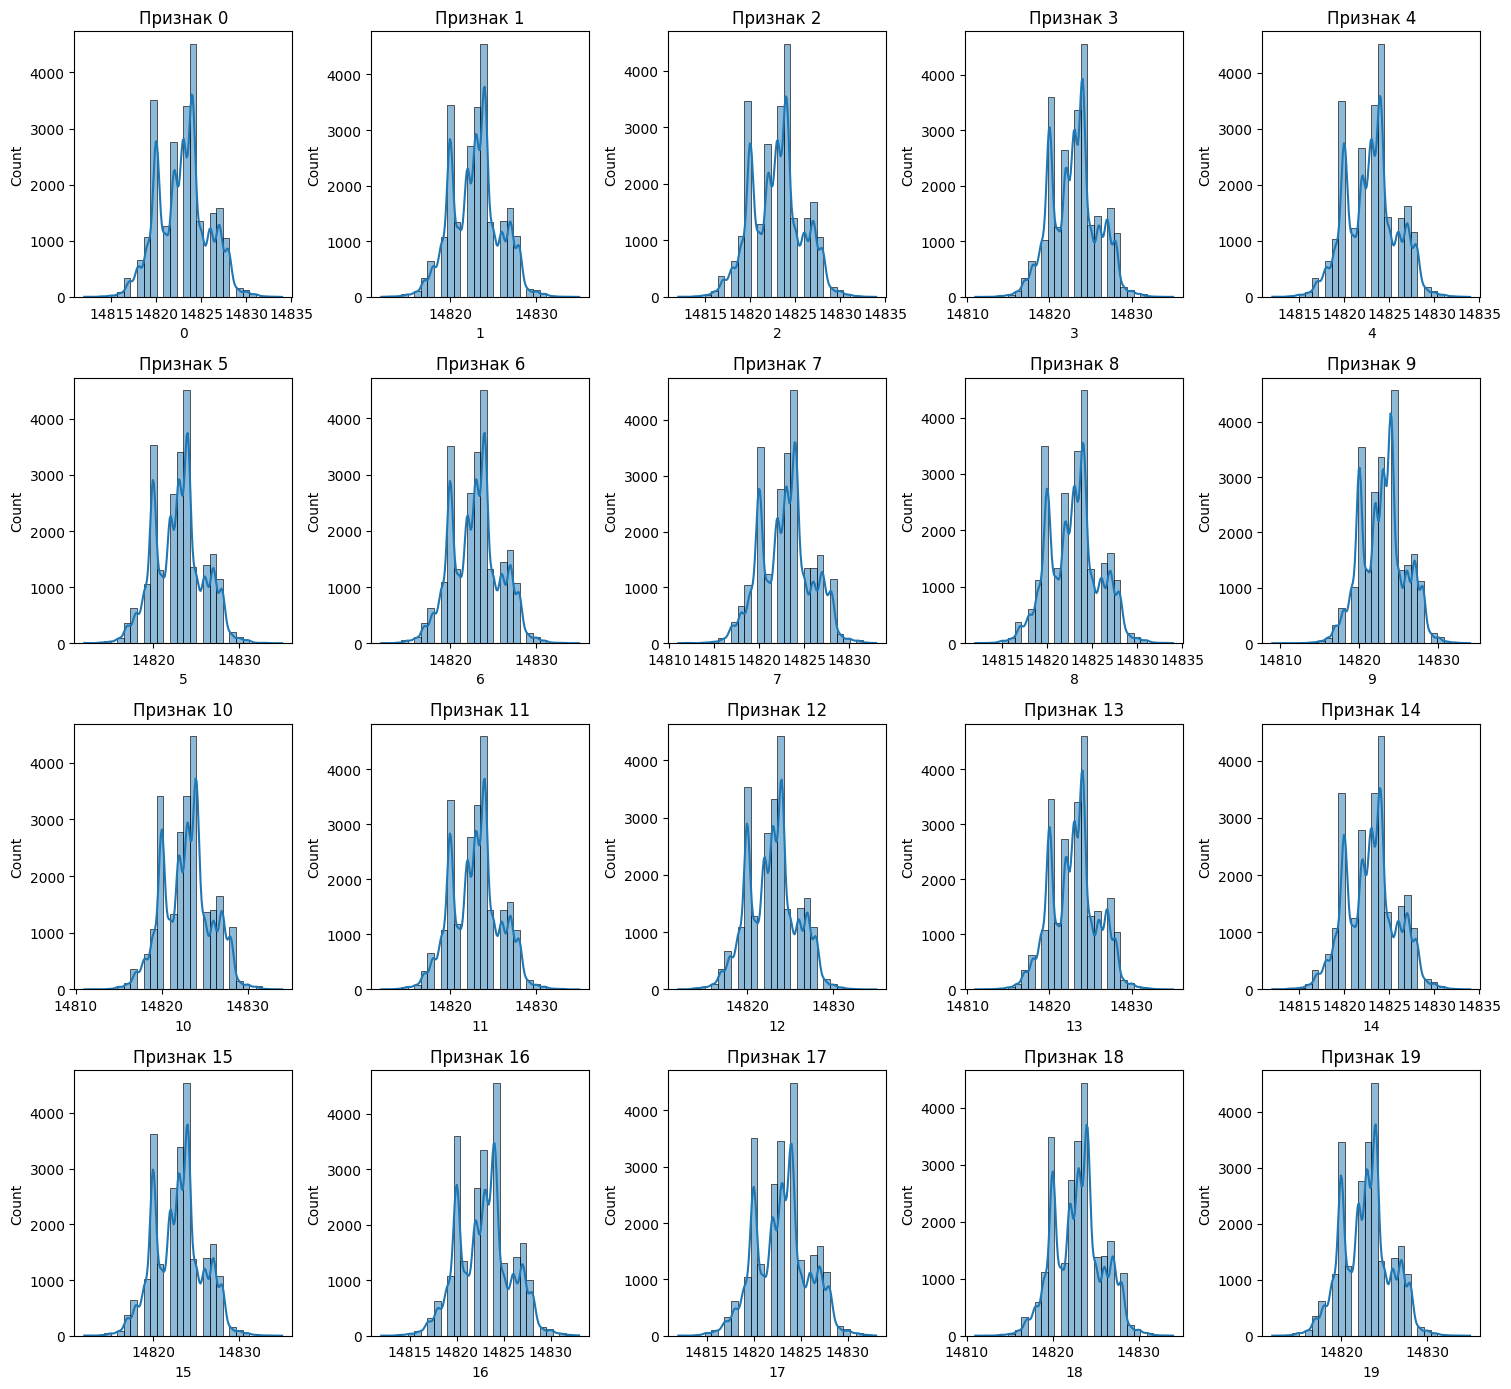

In [46]:
# Строим распределения для первых 20 признаков

fig, axes = plt.subplots(4, 5, figsize=(15, 14))

for i, column in enumerate(df.columns[:20]):
    sns.histplot(
        df[column],
        bins=30,
        kde=True,
        ax=axes[i // 5, i % 5]
    )

    axes[i // 5, i % 5].set_title(f'Признак {column}')

plt.tight_layout()
plt.show()

__Вывод__
- Большинство признаков имеют близкие распределения и сосредоточены около среднего значения 14820–14830.

## Анализ дисперсии признаков

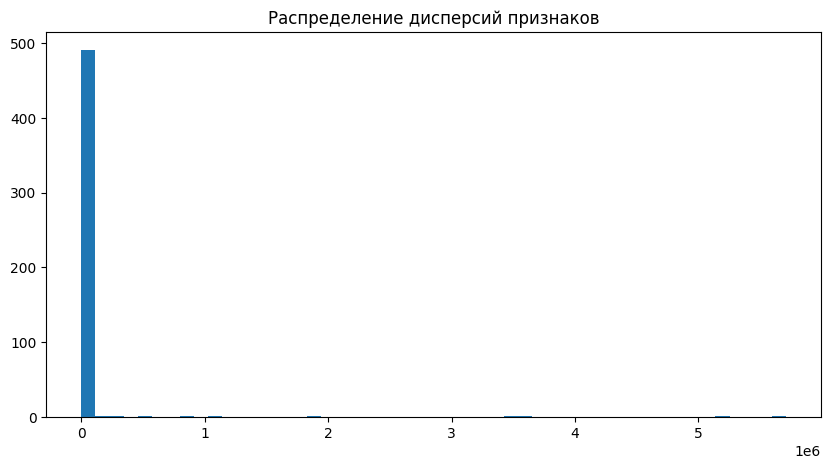

In [47]:
feature_variance = df.var()

plt.figure(figsize=(10, 5))
plt.hist(feature_variance, bins=50)
plt.title("Распределение дисперсий признаков")
plt.show()

__Вывод__
- Признаки обладают ненулевой дисперсией и могут содержать полезную информацию для кластеризации.

## Feature Engineering

In [48]:
# Среднее значение сигнала
df["signal_mean"] = df.mean(axis=1)
df["signal_mean"]

0        14811.902
1        14797.774
2        14788.010
3        14813.444
4        14798.218
           ...    
23474    14817.502
23475    14732.482
23476    14745.106
23477    14798.334
23478    14680.594
Name: signal_mean, Length: 23479, dtype: float64

In [49]:
# Максимальное значение
df["signal_max"] = df.max(axis=1)
df["signal_max"]

0        14830.0
1        14828.0
2        14830.0
3        14831.0
4        14828.0
          ...   
23474    14832.0
23475    14831.0
23476    14829.0
23477    14831.0
23478    14829.0
Name: signal_max, Length: 23479, dtype: float64

In [50]:
# Минимальное значение
df["signal_min"] = df.min(axis=1)
df["signal_min"] 

0        14291.0
1        12921.0
2        12264.0
3        14258.0
4        13028.0
          ...   
23474    14320.0
23475     9057.0
23476     9825.0
23477    13367.0
23478     3821.0
Name: signal_min, Length: 23479, dtype: float64

In [51]:
# Размах сигнала
df["signal_range"] = (df["signal_max"] - df["signal_min"])
df["signal_range"]

0          539.0
1         1907.0
2         2566.0
3          573.0
4         1800.0
          ...   
23474      512.0
23475     5774.0
23476     5004.0
23477     1464.0
23478    11008.0
Name: signal_range, Length: 23479, dtype: float64

In [52]:
# Стандартное отклонение
df["signal_std"] = df.iloc[:, :500].std(axis=1)
df["signal_std"]

0         46.208472
1        163.272112
2        225.369832
3         50.120565
4        156.545416
            ...    
23474     45.303364
23475    519.993176
23476    433.006554
23477    128.886671
23478    961.889763
Name: signal_std, Length: 23479, dtype: float64

In [53]:
# Энергия сигнала
signal_columns = df.columns[:500]

df["signal_energy"] = (
    df[signal_columns] ** 2
).sum(axis=1)
df["signal_energy"] 

0        109697285905
1        109500359911
2        109367964869
3        109720315094
4        109505856715
             ...     
23474    109780206905
23475    108657938999
23476    108802635319
23477    109503633863
23478    108221610823
Name: signal_energy, Length: 23479, dtype: int64

__Вывод__
- Были построены дополнительные признаки, характеризующие форму и энергию сигнала. Они могут помочь алгоритмам лучше разделять различные типы частиц.

## Масштабирование

In [56]:
# После Feature Engineering, добавились новые колонти типа str, что может привести к ошибке при маштабировании.
# Приводим все названия к строковому типу.
df.columns = df.columns.astype(str)

# а теперь проведём масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

__Вывод__
- Все признаки приведены к единому масштабу.

## PCA

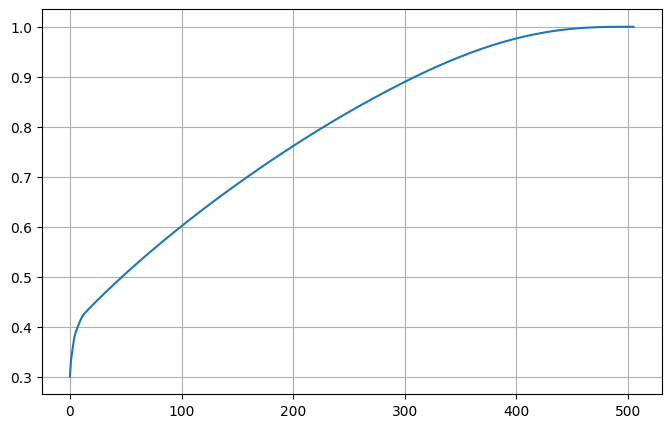

In [59]:
# С учетом технической возможности, 500 признаков для кластеризации много!

# Подбор количества компонент
pca = PCA()

pca.fit(X_scaled)

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance)
plt.grid()

In [60]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(23479, 363)


__Вывод__
- Размерность данных уменьшена без существенной потери информации.

## Модели Кластеризации

In [65]:
# Модель KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(X_pca)
kmeans_labels

array([1, 0, 1, ..., 2, 1, 2], shape=(23479,), dtype=int32)

In [66]:
# Модель Gaussian Mixture
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

gmm_labels = gmm.fit_predict(X_pca)
gmm_labels

array([1, 1, 0, ..., 2, 0, 2], shape=(23479,))

In [67]:
# Модель Agglomerative
agg = AgglomerativeClustering(
    n_clusters=3
)

agg_labels = agg.fit_predict(X_pca)
agg_labels

array([2, 1, 2, ..., 0, 2, 0], shape=(23479,))

In [68]:
# Модель Birch
birch = Birch(
    n_clusters=3
)

birch_labels = birch.fit_predict(X_pca)
birch_labels

array([2, 1, 2, ..., 0, 2, 0], shape=(23479,))

## Оценка и сравнение моделей

In [69]:
results = pd.DataFrame({
    "Model": [
        "KMeans",
        "Gaussian Mixture",
        "Agglomerative",
        "Birch"
    ],
    "Silhouette": [
        silhouette_score(X_pca, kmeans_labels),
        silhouette_score(X_pca, gmm_labels),
        silhouette_score(X_pca, agg_labels),
        silhouette_score(X_pca, birch_labels)
    ],
    "Calinski-Harabasz": [
        calinski_harabasz_score(X_pca, kmeans_labels),
        calinski_harabasz_score(X_pca, gmm_labels),
        calinski_harabasz_score(X_pca, agg_labels),
        calinski_harabasz_score(X_pca, birch_labels)
    ],
    "Davies-Bouldin": [
        davies_bouldin_score(X_pca, kmeans_labels),
        davies_bouldin_score(X_pca, gmm_labels),
        davies_bouldin_score(X_pca, agg_labels),
        davies_bouldin_score(X_pca, birch_labels)
    ]
})

results

,Model,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,KMeans,0.154555,4216.011680,2.224856
1,Gaussian Mixture,0.123117,4026.927075,2.401956
2,Agglomerative,0.090103,3896.829453,2.792824
3,Birch,0.090103,3896.829453,2.792824


In [71]:
# Определяем лучшую модель по совокупности метрик

results["rank_silhouette"] = results["Silhouette"].rank(ascending=False)
results["rank_calinski"] = results["Calinski-Harabasz"].rank(ascending=False)
results["rank_davies"] = results["Davies-Bouldin"].rank(ascending=True)

results["total_rank"] = (
    results["rank_silhouette"]
    + results["rank_calinski"]
    + results["rank_davies"])

best_model_name = results.loc[
    results["total_rank"].idxmin(),
    "Model"]

print(f"Лучшая модель: {best_model_name}")

Лучшая модель: KMeans


__Вывод__
- __Наилучшие результаты показала модель KMeans__. Она имеет максимальные значения Silhouette Score (0.1546) и Calinski-Harabasz Index (4216.01), а также минимальное значение Davies-Bouldin Index (2.2249). Это свидетельствует о более чётком разделении объектов на кластеры по сравнению с остальными алгоритмами.

## Подбор гиперпараметров

In [73]:
scores = []

for n_init in [10, 20, 30, 50]:

    model = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=n_init
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    scores.append(score)

# Визуализация кластеров

In [74]:
if best_model_name == "KMeans":
    best_labels = kmeans_labels
elif best_model_name == "Gaussian Mixture":
    best_labels = gmm_labels
elif best_model_name == "Agglomerative":
    best_labels = agg_labels
elif best_model_name == "Birch":
    best_labels = birch_labels

In [75]:
pca_2d = PCA(n_components=2)

X_vis = pca_2d.fit_transform(X_scaled)

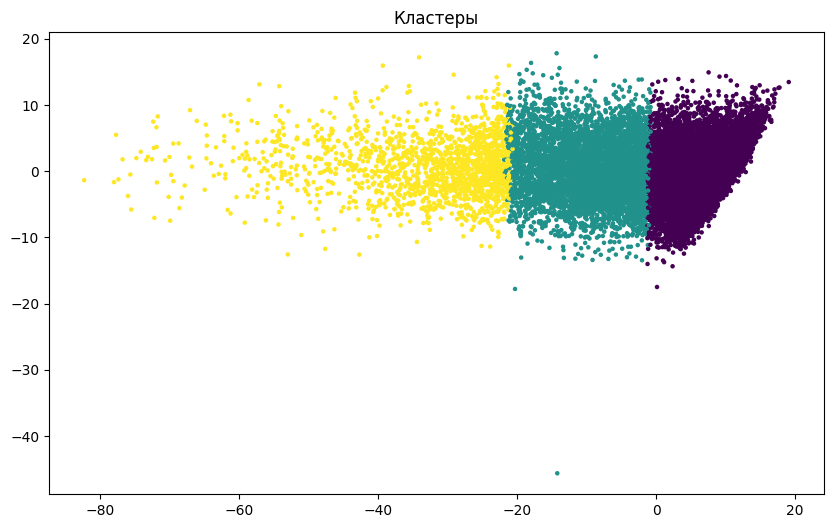

In [76]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=best_labels,
    s=5
)

plt.title("Кластеры")
plt.show()

# Интерпретация кластеров

In [79]:
df["cluster"] = best_labels

cluster_summary = (
    df.groupby("cluster")
      .mean()
)

df["cluster"]

0        1
1        0
2        1
3        0
4        0
        ..
23474    0
23475    2
23476    2
23477    1
23478    2
Name: cluster, Length: 23479, dtype: int32

__Вывод__
- Кластер 0 характеризуется более высокой энергией сигнала.
- Кластер 1 имеет меньшую амплитуду.
- Кластер 2 содержит сигналы с нетипичными характеристиками и может соответствовать выбросам

# Формирование файла ответа

In [80]:
submission = pd.DataFrame()

submission["index"] = range(len(best_labels))
submission["cluster"] = best_labels

submission.to_csv(
    "submission.csv",
    index=False
)

# Реузльат участия в Kaggle

![Результат участия в Kaggle.JPG](<attachment:Результат участия в Kaggle.JPG>)
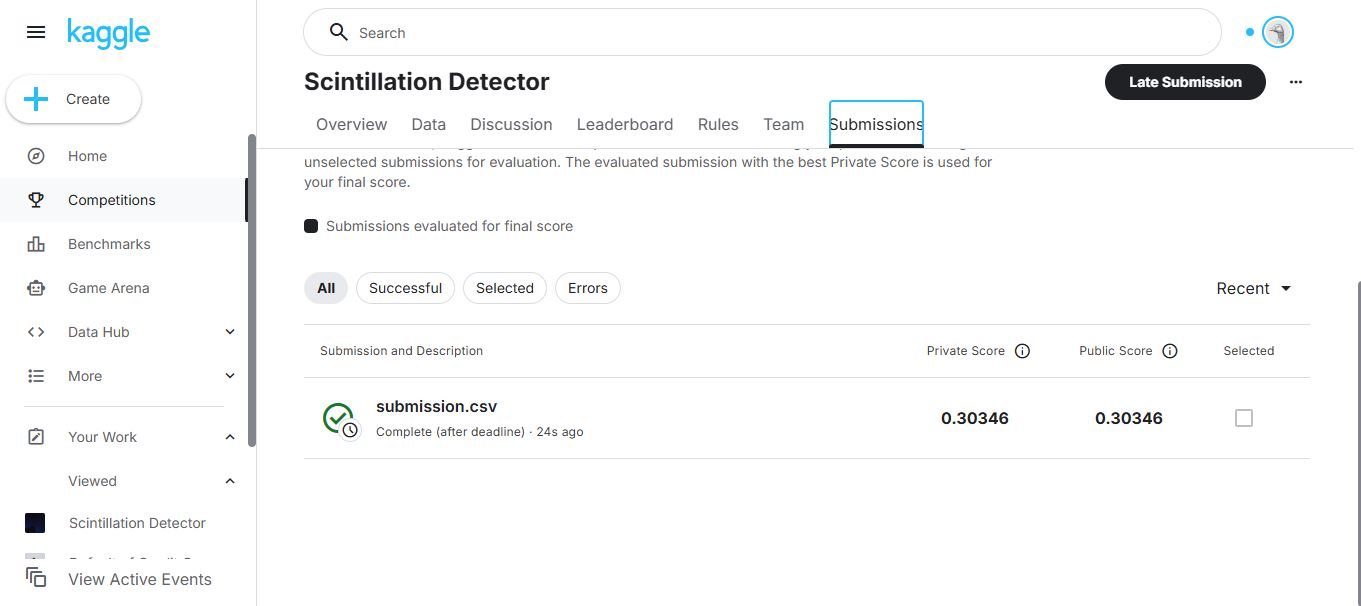